# So sánh toàn bộ độ đo — mỗi hình ứng với 1 cổ phiếu

Notebook này giữ nguyên phần đọc dữ liệu và tính thống kê, nhưng **mỗi hình chỉ ứng với một cổ phiếu**.

- Mỗi hình chứa **6 độ đo**.
- Đã **loại bỏ ROI (%)** khỏi phần thống kê và trực quan hóa.
- Mỗi subplot vẫn so sánh 2 giai đoạn `GOOD` / `BAD` và 3 chiến lược: UCB-VAE, Epsilon-Greedy, Buy-and-Hold.
- Deep SARSA UCB-VAE và Epsilon-Greedy: mean ± sample standard deviation trên 20 seed.
- Buy-and-Hold: baseline xác định (`n=1`, SD bằng 0).

Thứ tự các độ đo trong mỗi hình:
1. Final Profit
2. ARR (%)
3. Volatility (%)
4. Sharpe Ratio
5. Maximum Drawdown (%)
6. Constraint Violations


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TICKERS = ("ACB", "FPT", "GAS", "HPG", "SSI", "VCB")
PERIODS = ("GOOD", "BAD")
MODEL_LABELS = {
    "UNCERTAINTY_AWARE_UCB_009": "UCB-VAE",
    "EPSILON_GREEDY": "Epsilon-Greedy",
    "BUY_AND_HOLD": "Buy-and-Hold",
}

# Giữ nguyên thứ tự độ đo để cách trình bày giữa 6 cổ phiếu hoàn toàn đồng nhất.
METRICS = {
    "profit": ("Final Profit", "test_profit"),
    "arr": ("ARR (%)", "test_arr"),
    "volatility": ("Volatility (%)", "test_volatility"),
    "sharpe": ("Sharpe Ratio", "test_sharpe"),
    "max_drawdown": ("Maximum Drawdown (%)", "test_max_drawdown"),
    "violations": ("Constraint Violations", "test_violations"),
}

def find_project_root():
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "application" / "EIDT_Project" / "final_result").exists():
            return candidate
    raise FileNotFoundError(
        "Không tìm thấy project root có application/EIDT_Project/final_result"
    )

ROOT = find_project_root()
SOURCE = ROOT / "application" / "EIDT_Project" / "final_result"

# Tách folder output mới để không ghi đè các hình 6-stock của notebook cũ.
OUTPUT = ROOT / "application" / "FAIR_2026" / "metric_comparison_by_stock"
OUTPUT.mkdir(parents=True, exist_ok=True)

def period_dir(ticker, period):
    found = [
        p for p in (SOURCE / ticker).iterdir()
        if p.is_dir() and p.name.upper() == period
    ]
    if len(found) != 1:
        raise FileNotFoundError(f"Không xác định được folder {ticker}/{period}")
    return found[0]

print("Project root:", ROOT)
print("Source:", SOURCE)
print("Output:", OUTPUT)


Project root: D:\NCKH\SARSA_FinancialRL
Source: D:\NCKH\SARSA_FinancialRL\application\EIDT_Project\final_result
Output: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock


In [2]:
rows = []

for ticker in TICKERS:
    for period in PERIODS:
        folder = period_dir(ticker, period)

        # Hai tác nhân RL: kiểm tra đủ 20 seed.
        rl = pd.read_csv(folder / "rl_metrics.csv")

        for model_key in ("UNCERTAINTY_AWARE_UCB_009", "EPSILON_GREEDY"):
            group = rl.loc[rl.model_key == model_key].copy()

            if len(group) != 20 or group.seed.nunique() != 20:
                raise ValueError(
                    f"{ticker}/{period}/{model_key} không có đúng 20 seed"
                )

            for metric, (_, column) in METRICS.items():
                values = pd.to_numeric(group[column], errors="raise")

                if not np.isfinite(values).all():
                    raise ValueError(
                        f"Giá trị không hữu hạn: {ticker}/{period}/{column}"
                    )

                rows.append({
                    "ticker": ticker,
                    "period": period,
                    "model_key": model_key,
                    "strategy": MODEL_LABELS[model_key],
                    "metric": metric,
                    "n": 20,
                    "mean": float(values.mean()),
                    "std": float(values.std(ddof=1)),
                })

        # Buy-and-Hold: n = 1, std = 0.
        hold = pd.read_csv(folder / "buy_and_hold_metrics.csv")

        for metric, (_, column) in METRICS.items():
            value = float(pd.to_numeric(hold[column], errors="raise").iloc[0])

            rows.append({
                "ticker": ticker,
                "period": period,
                "model_key": "BUY_AND_HOLD",
                "strategy": MODEL_LABELS["BUY_AND_HOLD"],
                "metric": metric,
                "n": 1,
                "mean": value,
                "std": 0.0,
            })

summary = pd.DataFrame(rows)

expected = len(TICKERS) * len(PERIODS) * len(MODEL_LABELS) * len(METRICS)
assert len(summary) == expected

summary_file = OUTPUT / "all_metrics_6stocks_good_bad.csv"
summary.to_csv(summary_file, index=False)

print(f"Đã kiểm tra {len(summary)} ô thống kê ({expected} kỳ vọng).")
print("Saved summary:", summary_file)

summary.head(10)


Đã kiểm tra 216 ô thống kê (216 kỳ vọng).
Saved summary: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\all_metrics_6stocks_good_bad.csv


,ticker,period,model_key,strategy,metric,n,mean,std
0,ACB,GOOD,UNCERTAINTY_AWARE_UCB_009,UCB-VAE,profit,20,619.077718,573.575229
1,ACB,GOOD,UNCERTAINTY_AWARE_UCB_009,UCB-VAE,arr,20,15.895076,13.852042
2,ACB,GOOD,UNCERTAINTY_AWARE_UCB_009,UCB-VAE,volatility,20,15.395711,11.390479
3,ACB,GOOD,UNCERTAINTY_AWARE_UCB_009,UCB-VAE,sharpe,20,-9.514789,43.590751
4,ACB,GOOD,UNCERTAINTY_AWARE_UCB_009,UCB-VAE,max_drawdown,20,16.796858,12.389686
5,ACB,GOOD,UNCERTAINTY_AWARE_UCB_009,UCB-VAE,violations,20,4.850000,5.450978
6,ACB,GOOD,EPSILON_GREEDY,Epsilon-Greedy,profit,20,581.310606,582.006579
7,ACB,GOOD,EPSILON_GREEDY,Epsilon-Greedy,arr,20,14.913088,14.014992
8,ACB,GOOD,EPSILON_GREEDY,Epsilon-Greedy,volatility,20,14.272301,11.264257
9,ACB,GOOD,EPSILON_GREEDY,Epsilon-Greedy,sharpe,20,-0.092681,2.094406


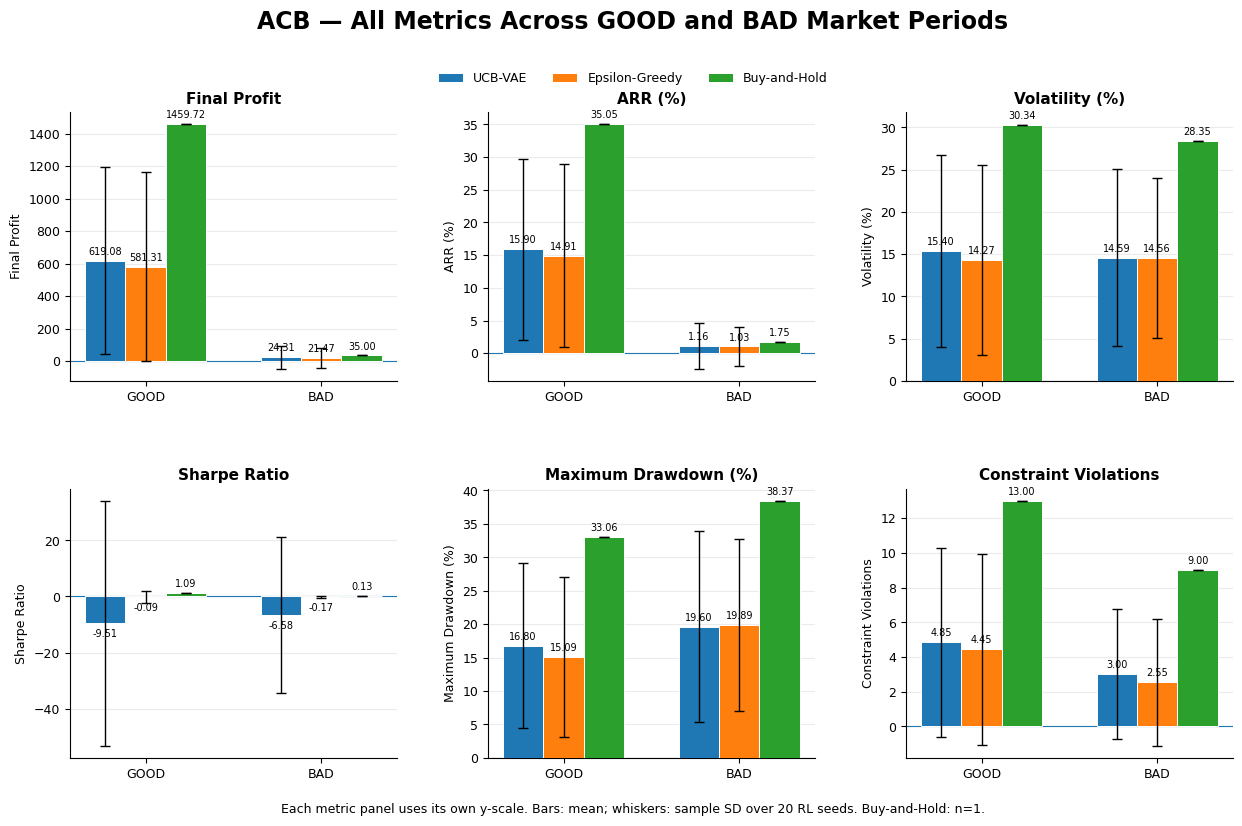

Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\acb_all_metrics_good_bad.png
Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\acb_all_metrics_good_bad.pdf


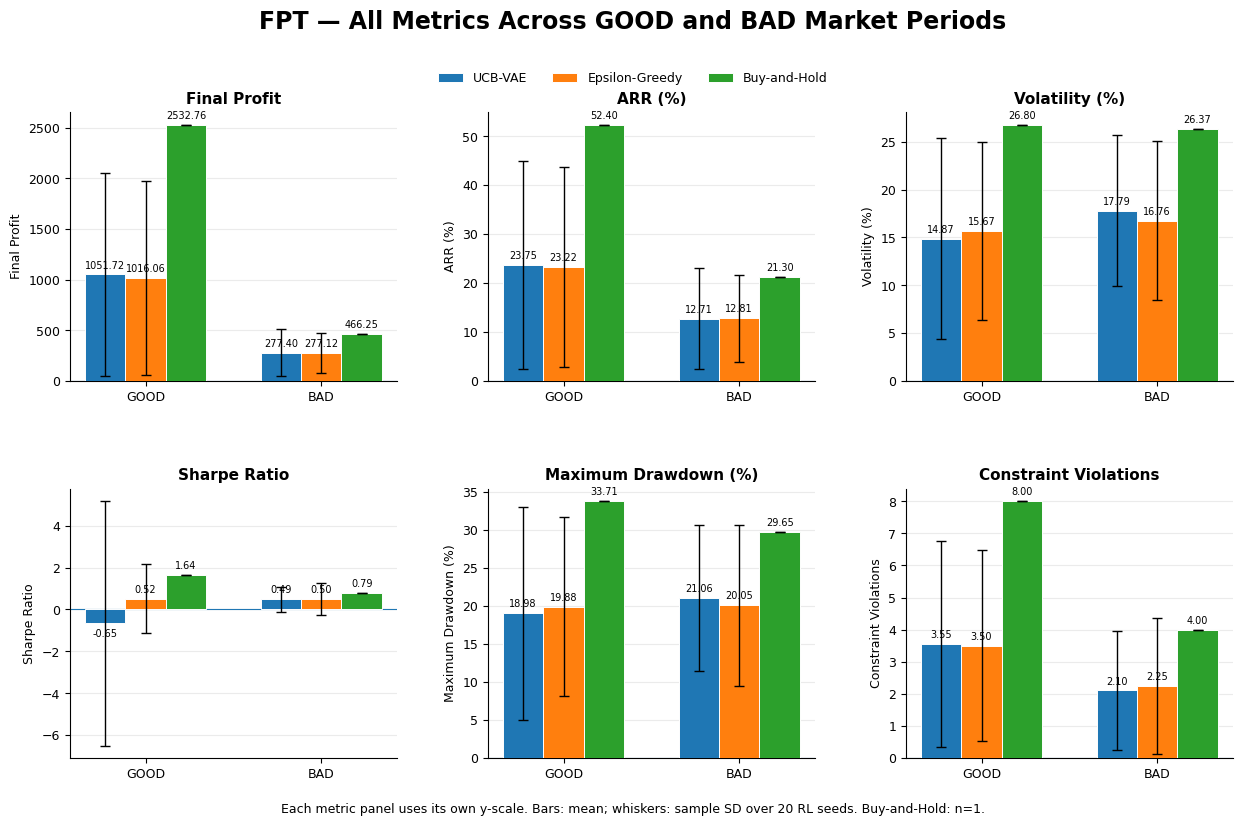

Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\fpt_all_metrics_good_bad.png
Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\fpt_all_metrics_good_bad.pdf


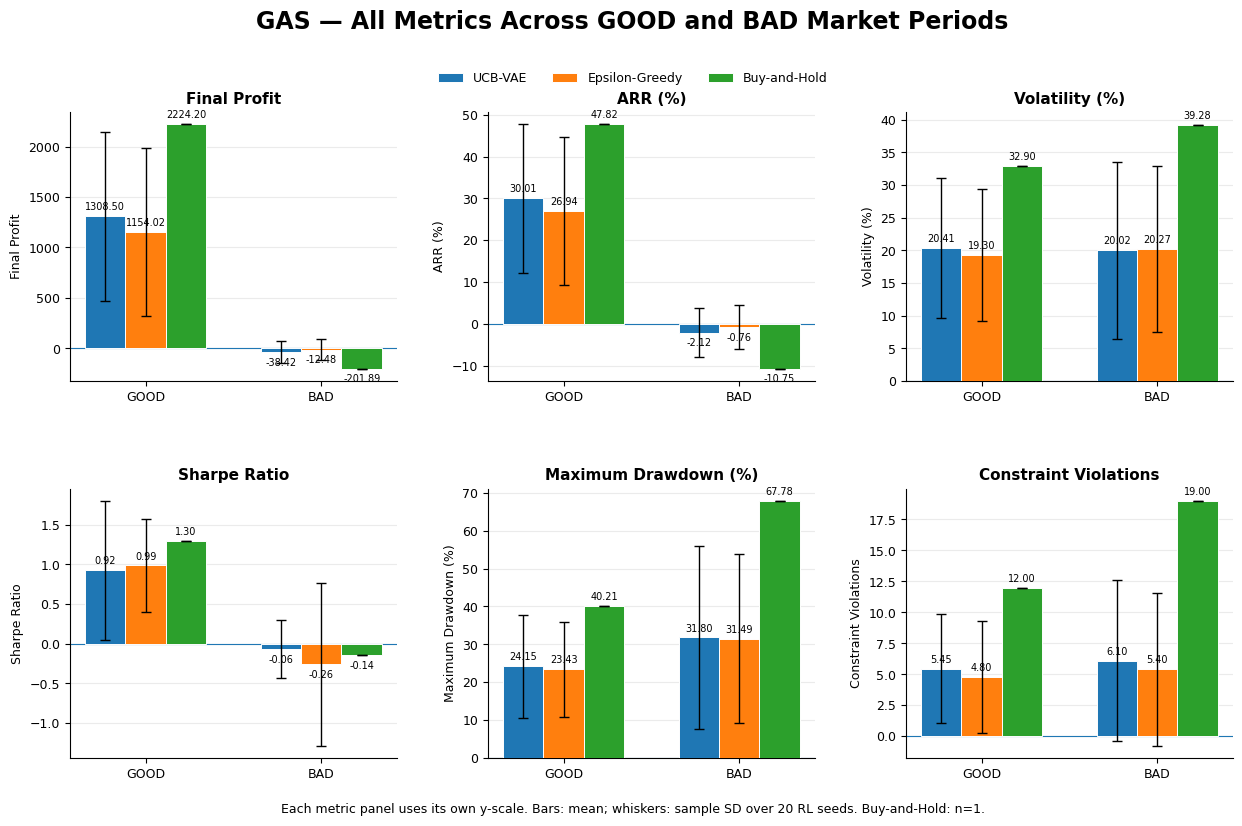

Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\gas_all_metrics_good_bad.png
Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\gas_all_metrics_good_bad.pdf


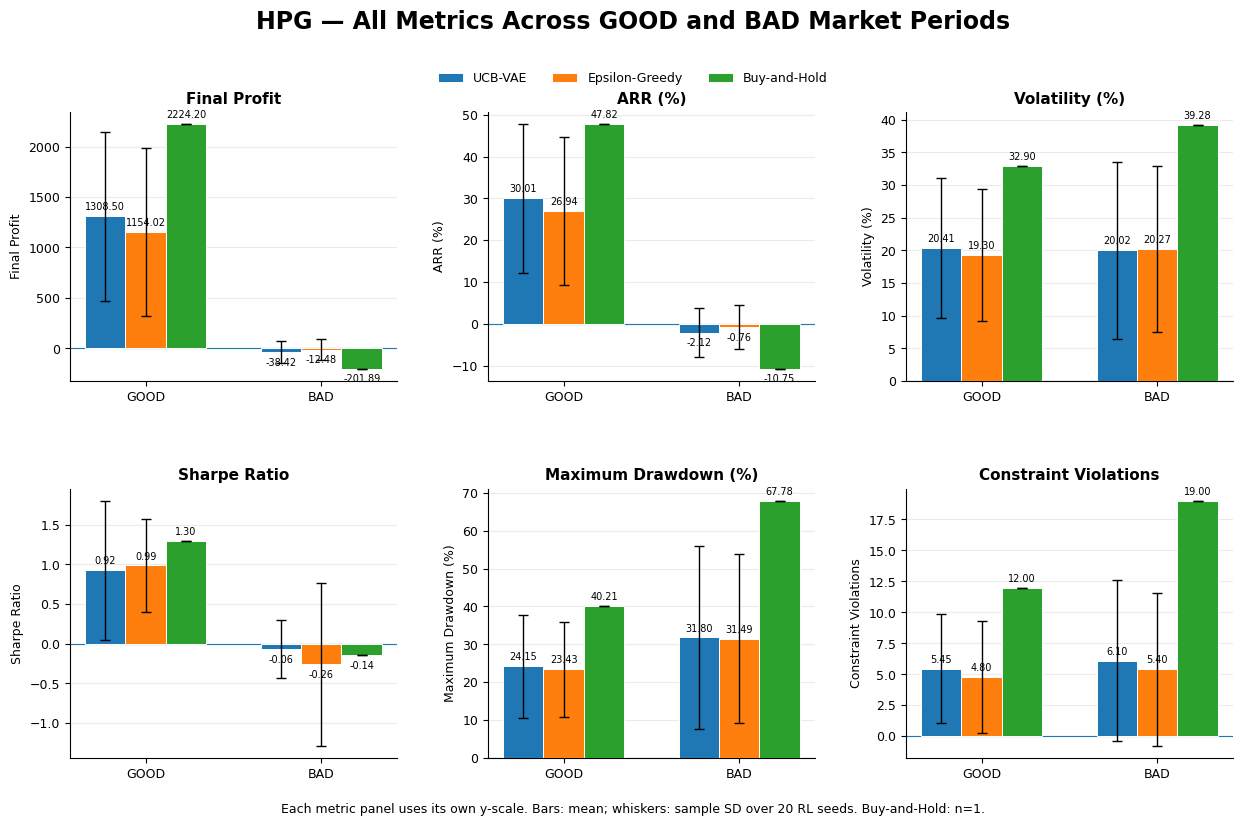

Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\hpg_all_metrics_good_bad.png
Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\hpg_all_metrics_good_bad.pdf


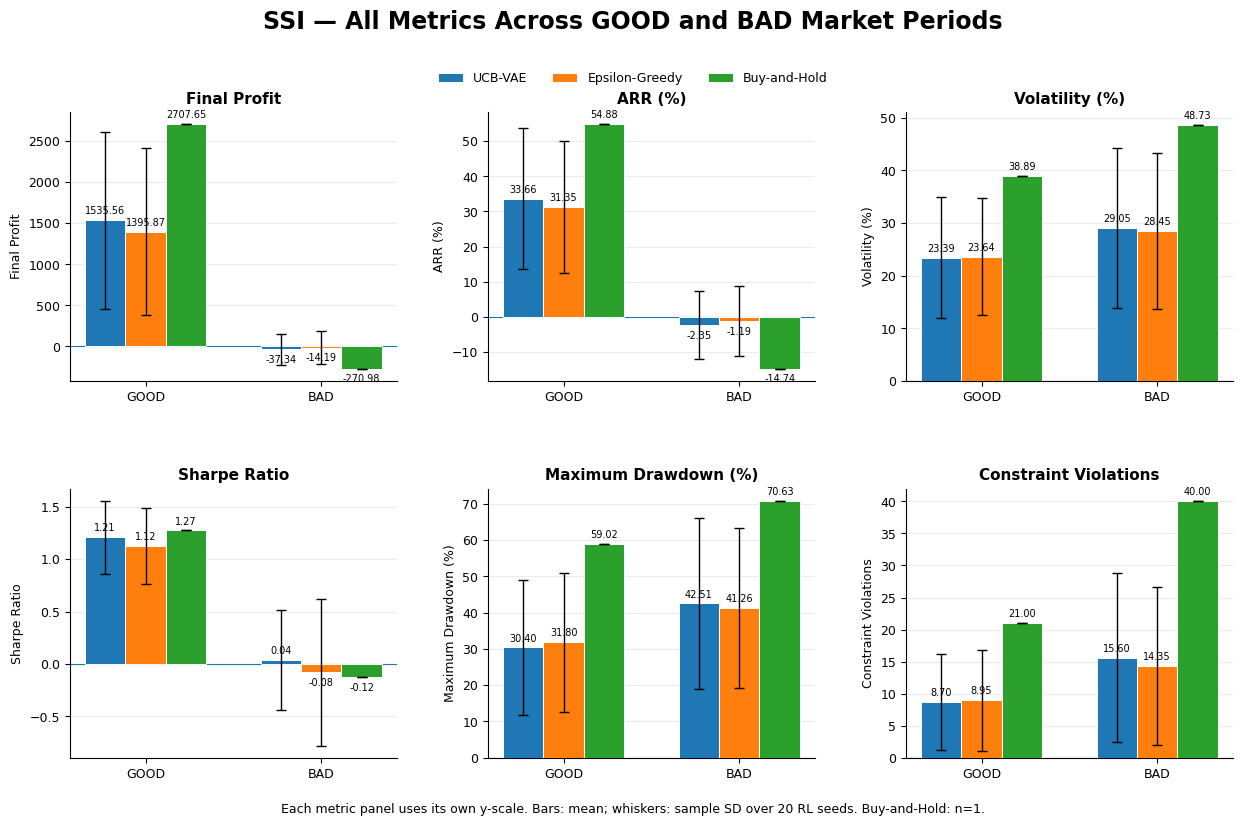

Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\ssi_all_metrics_good_bad.png
Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\ssi_all_metrics_good_bad.pdf


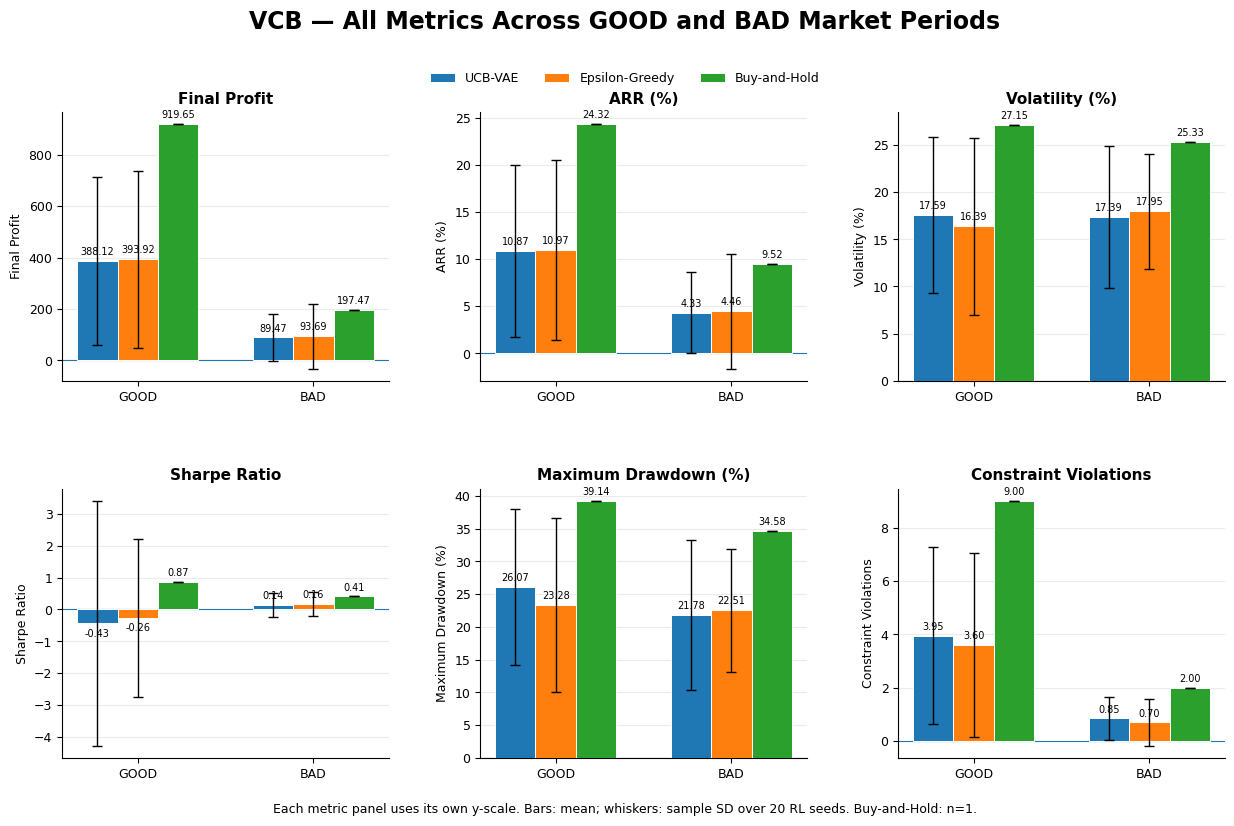

Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\vcb_all_metrics_good_bad.png
Saved: D:\NCKH\SARSA_FinancialRL\application\FAIR_2026\metric_comparison_by_stock\vcb_all_metrics_good_bad.pdf
Đã tạo 6 hình PNG và 6 PDF (12 file hình tổng cộng).


In [3]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titleweight": "bold",
})

strategies = list(MODEL_LABELS.values())
x = np.arange(len(PERIODS), dtype=float)
width = 0.23

saved_figures = []

def annotate_bars(ax, bars, means):
    for bar, mean in zip(bars, means):
        ax.annotate(
            f"{mean:.2f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3 if mean >= 0 else -4),
            textcoords="offset points",
            ha="center",
            va="bottom" if mean >= 0 else "top",
            fontsize=7,
        )

def plot_one_stock(ticker):
    stock_frame = summary[summary.ticker == ticker].copy()

    # 2 x 3: đúng 6 độ đo cho một cổ phiếu.
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    axes = axes.ravel()

    fig.subplots_adjust(
        top=0.86,
        bottom=0.10,
        hspace=0.40,
        wspace=0.28,
    )

    for metric_index, (metric, (title, _)) in enumerate(METRICS.items()):
        ax = axes[metric_index]
        metric_frame = stock_frame[stock_frame.metric == metric]

        for strategy_index, strategy in enumerate(strategies):
            ordered = (
                metric_frame[metric_frame.strategy == strategy]
                .set_index("period")
                .loc[list(PERIODS)]
            )

            offset = (strategy_index - 1) * width

            bars = ax.bar(
                x + offset,
                ordered["mean"],
                width,
                yerr=ordered["std"],
                capsize=3.5,
                edgecolor="white",
                linewidth=0.7,
                label=strategy,
                zorder=3,
                error_kw={"elinewidth": 1, "capthick": 1},
            )

            annotate_bars(ax, bars, ordered["mean"])

        ax.axhline(0, linewidth=0.8)
        ax.set_xticks(x, PERIODS)
        ax.set_title(title, fontsize=11)
        ax.set_ylabel(title)
        ax.grid(axis="y", alpha=0.25, zorder=0)
        ax.spines[["top", "right"]].set_visible(False)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.92),
        frameon=False,
    )

    fig.suptitle(
        f"{ticker} — All Metrics Across GOOD and BAD Market Periods",
        fontsize=17,
        fontweight="bold",
        y=0.98,
    )

    fig.text(
        0.5,
        0.035,
        "Each metric panel uses its own y-scale. "
        "Bars: mean; whiskers: sample SD over 20 RL seeds. "
        "Buy-and-Hold: n=1.",
        ha="center",
        fontsize=9,
    )

    png = OUTPUT / f"{ticker.lower()}_all_metrics_good_bad.png"
    pdf = OUTPUT / f"{ticker.lower()}_all_metrics_good_bad.pdf"

    fig.savefig(png, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")

    plt.show()
    plt.close(fig)

    saved_figures.extend([png, pdf])
    print("Saved:", png)
    print("Saved:", pdf)


# Tạo đúng 6 hình chính: mỗi cổ phiếu một hình, trong hình có đủ 6 độ đo.
for ticker in TICKERS:
    plot_one_stock(ticker)

print(
    f"Đã tạo {len(TICKERS)} hình PNG và {len(TICKERS)} PDF "
    f"({len(saved_figures)} file hình tổng cộng)."
)


## Kết quả được tạo

Sau khi chạy notebook, thư mục `application/FAIR_2026/metric_comparison_by_stock/` sẽ có:

- `acb_all_metrics_good_bad.png` và `.pdf`
- `fpt_all_metrics_good_bad.png` và `.pdf`
- `gas_all_metrics_good_bad.png` và `.pdf`
- `hpg_all_metrics_good_bad.png` và `.pdf`
- `ssi_all_metrics_good_bad.png` và `.pdf`
- `vcb_all_metrics_good_bad.png` và `.pdf`
- `all_metrics_6stocks_good_bad.csv` — bảng thống kê tổng hợp **không còn ROI (%)**.

Mỗi hình của một cổ phiếu gồm 6 subplot theo cùng thứ tự: Final Profit, ARR, Volatility, Sharpe Ratio, Maximum Drawdown, Constraint Violations.
